# Dataset Exploration and Preprocessing

In this section, I load and explore the network datasets used in this project.  
The goal of this exploratory analysis is to understand the structural properties of each network before applying machine learning models for link prediction.

All datasets are obtained from the Stanford SNAP Large Network Dataset Collection, which provides real-world network data commonly used in network science and machine learning research.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/AI_Agent_Social_Network_Project"
os.makedirs(project_path, exist_ok=True)

## Reusable Network Exploratory Data Analysis Function

Because this project analyzes multiple network datasets, I define a reusable function that performs the same exploratory analysis for any graph. This allows the analysis to remain consistent across datasets while avoiding repeated code.

The function computes basic network statistics and generates several standard network science visualizations, including:

- Degree distribution
- Log-scaled degree distribution
- Clustering coefficient distribution
- A small network visualization

Using this reusable function ensures that each dataset is analyzed using the same exploratory framework.

In [34]:
# I define a reusable function that runs exploratory analysis on any network
def run_network_eda(G, name):

    import networkx as nx
    import matplotlib.pyplot as plt

    # I compute and print basic summary statistics describing the network
    print("\n---", name, "---")
    print("Nodes:", G.number_of_nodes())
    print("Edges:", G.number_of_edges())
    print("Density:", nx.density(G))
    print("Average clustering:", nx.average_clustering(G))

    # I compute the degree for every node in the network
    degrees = [d for n, d in G.degree()]

    # I plot the degree distribution
    plt.hist(degrees, bins=50)
    plt.xlim(0,300)
    plt.title("Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()

    # I plot the log-scaled degree distribution to better visualize heavy tails
    plt.hist(degrees, bins=50, log=True)
    plt.title("Log Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Log Frequency")
    plt.show()

    # I compute clustering coefficients for all nodes
    clustering_vals = list(nx.clustering(G).values())

    # I plot the clustering coefficient distribution
    plt.hist(clustering_vals, bins=50)
    plt.title("Clustering Coefficient Distribution")
    plt.xlabel("Clustering Coefficient")
    plt.ylabel("Frequency")
    plt.show()

    # I select a small subset of nodes so the visualization stays readable
    sample_nodes = list(G.nodes())[:200]

    # I create a subgraph induced by the sampled nodes
    subG = G.subgraph(sample_nodes)

    # I draw the sampled subgraph
    plt.figure(figsize=(8,8))
    nx.draw(
        subG,
        node_size=20,
        node_color="steelblue",
        edge_color="gray",
        alpha=0.6,
        width=0.5
    )
    plt.title(f"Sample {name} Network Subgraph")
    plt.show()


### Dataset 1: Facebook Social Circles Network

The first dataset used in this project is the Facebook Social Circles network from the Stanford SNAP Large Network Dataset Collection. In this dataset, nodes represent Facebook users and edges represent friendship relationships between users. The network contains 4,039 nodes and 88,234 edges, forming a dense social network with strong local clustering. This dataset is well suited for link prediction experiments because social networks typically exhibit triadic closure, meaning that friends of friends are more likely to form new connections.

In [55]:
# I download the Facebook Social Circles dataset from the SNAP collection

import urllib.request

url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
path = f"{project_path}/facebook_combined.txt.gz"

urllib.request.urlretrieve(url, path)

print("Saved to:", path)

Saved to: /content/drive/MyDrive/AI_Agent_Social_Network_Project/facebook_combined.txt.gz


In [56]:
# I unzip the Facebook dataset so it can be read as a plain edge list

import gzip
import shutil

with gzip.open(path, 'rb') as f_in:
    with open(f"{project_path}/facebook_edges.txt", 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Unzipped to:", f"{project_path}/facebook_edges.txt")

Unzipped to: /content/drive/MyDrive/AI_Agent_Social_Network_Project/facebook_edges.txt


In [58]:
import pandas as pd
import networkx as nx

# I load the Facebook edge list into a dataframe
facebook_edges_path = f"{project_path}/facebook_edges.txt"
edges_facebook = pd.read_csv(
    facebook_edges_path,
    sep=" ",
    header=None,
    names=["u", "v"]
)

print("Facebook edge sample:")
print(edges_facebook.head())

# I construct the Facebook graph
G_facebook = nx.from_pandas_edgelist(edges_facebook, source="u", target="v")

print("Facebook nodes:", G_facebook.number_of_nodes())
print("Facebook edges:", G_facebook.number_of_edges())

Facebook edge sample:
   u  v
0  0  1
1  0  2
2  0  3
3  0  4
4  0  5
Facebook nodes: 4039
Facebook edges: 88234


### Basic Network Statistics

I first compute basic statistics describing the structure of the Facebook network.  
These statistics help characterize the size, density, and clustering patterns of the network.


--- Facebook Social Circles ---
Nodes: 4039
Edges: 88234
Density: 0.010819963503439287
Average clustering: 0.6055467186200862


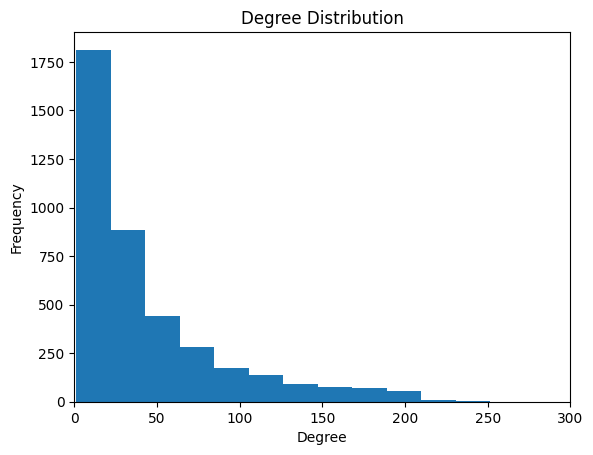

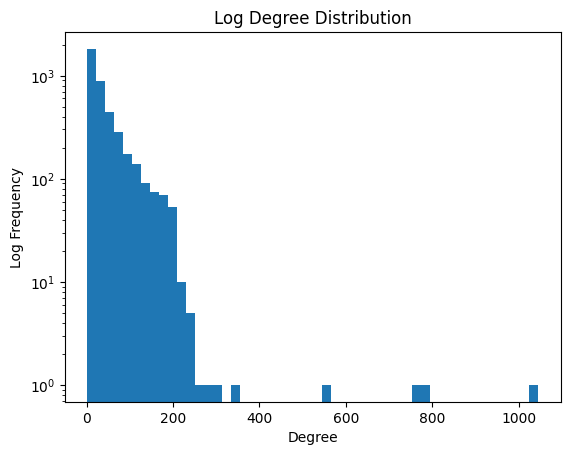

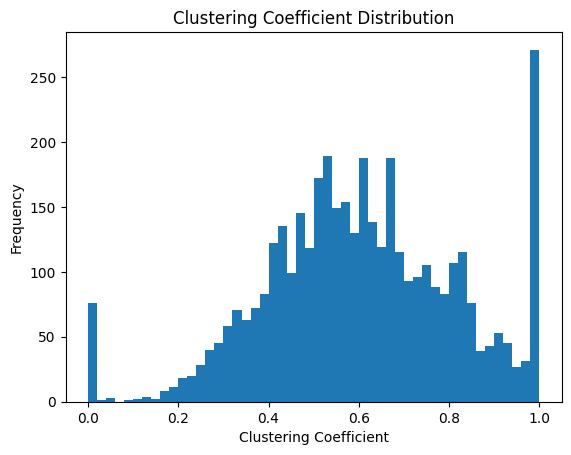

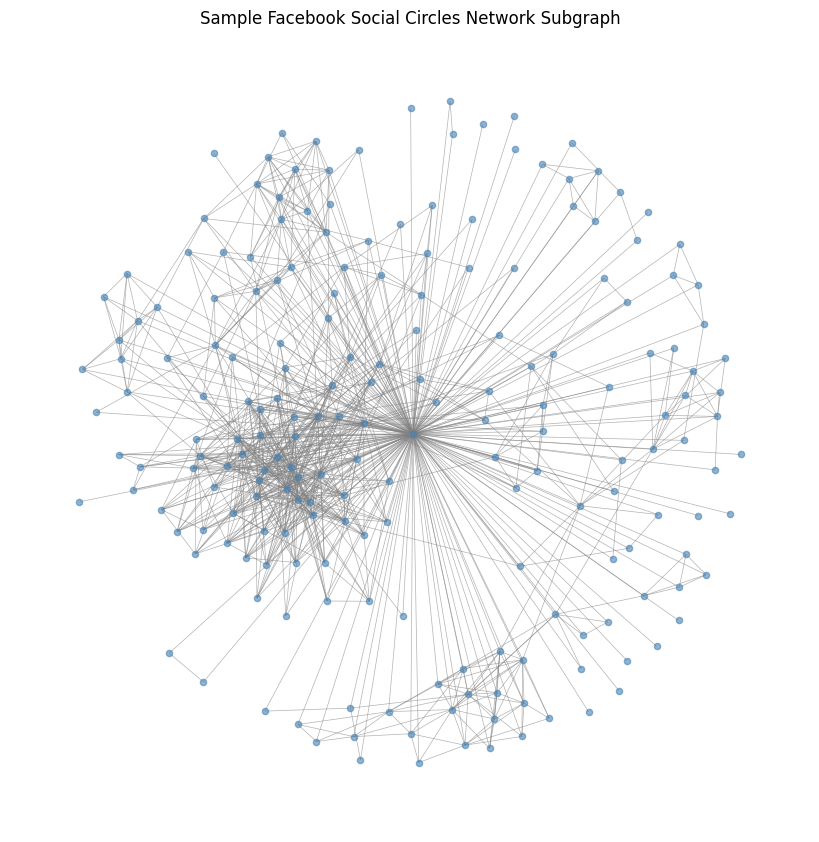

In [61]:
# I run the reusable EDA pipeline for the Facebook network
run_network_eda(G_facebook, "Facebook Social Circles")

Social networks typically exhibit heavy-tailed degree distributions, meaning that most nodes have relatively few connections while a small number of nodes have very large numbers of connections.

The degree distribution and log-scaled degree distribution shown above follow this expected pattern. Most nodes have a small degree, while a small number of nodes have extremely high degree. This indicates the presence of **hub nodes**, which are highly connected individuals that play an important role in the structure of the network.

The sampled network visualization further illustrates this structure. A few highly connected nodes appear near the center of the network, while many lower-degree nodes appear toward the periphery. This hub-and-spoke pattern is commonly observed in real-world social networks.

The clustering coefficient distribution also shows relatively high clustering values for many nodes. This suggests that users tend to form locally dense communities, where friends of friends are likely to be connected with one another. This pattern reflects the principle of **triadic closure**, which is a common property of social networks.

Together, these structural patterns indicate that the network contains meaningful relational signals that can help predict missing edges. As a result, this dataset provides an appropriate benchmark for evaluating link prediction models.

## Dataset 2: Email Communication Network

The second dataset used in this project is the Email Communication Network from the Stanford SNAP Large Network Dataset Collection. In this dataset, nodes represent individuals within a European research institution and edges represent email messages sent between users. Because email communication is directional, the network is modeled as a directed graph where edges capture the flow of information from one individual to another. Unlike the Facebook friendship network, which reflects mutual social relationships, the email network represents patterns of organizational communication and information exchange. This dataset therefore provides a useful contrast for evaluating whether link prediction methods generalize across different types of social interactions, including both reciprocal social ties and directed communication networks.


In [63]:
# I download the email communication dataset from the SNAP collection

import urllib.request

url = "https://snap.stanford.edu/data/email-Eu-core.txt.gz"
path = f"{project_path}/email_eu_core.txt.gz"

urllib.request.urlretrieve(url, path)

print("Saved to:", path)

Saved to: /content/drive/MyDrive/AI_Agent_Social_Network_Project/email_eu_core.txt.gz


In [64]:
# I unzip the dataset so it can be read as a plain edge list

import gzip
import shutil

with gzip.open(path, 'rb') as f_in:
    with open(f"{project_path}/email_edges.txt", 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Unzipped to:", f"{project_path}/email_edges.txt")

Unzipped to: /content/drive/MyDrive/AI_Agent_Social_Network_Project/email_edges.txt


In [65]:
import pandas as pd

# I load the email edge list into a dataframe
email_edges_path = f"{project_path}/email_edges.txt"

edges_email = pd.read_csv(
    email_edges_path,
    sep=" ",
    header=None,
    names=["u", "v"]
)

print("Email edge sample:")
print(edges_email.head())

print("Total edges:", len(edges_email))

Email edge sample:
   u  v
0  0  1
1  2  3
2  2  4
3  5  6
4  5  7
Total edges: 25571


In [71]:
import networkx as nx

# I construct a directed graph because email interactions have direction
G_email = nx.from_pandas_edgelist(
    edges_email,
    source="u",
    target="v",
    create_using=nx.DiGraph()
)

print("Email nodes:", G_email.number_of_nodes())
print("Email edges:", G_email.number_of_edges())

Email nodes: 1005
Email edges: 25571


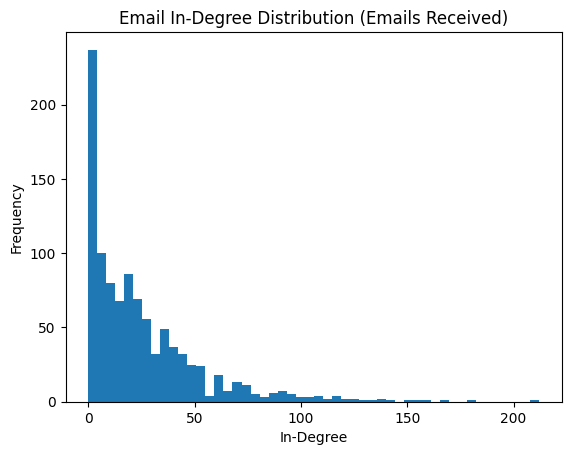

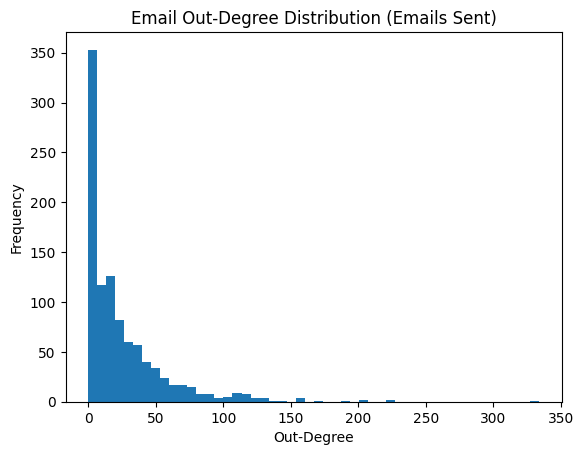

In [75]:
in_deg = [d for n, d in G_email.in_degree()]
out_deg = [d for n, d in G_email.out_degree()]

plt.hist(in_deg, bins=50)
plt.title("Email In-Degree Distribution (Emails Received)")
plt.xlabel("In-Degree")
plt.ylabel("Frequency")
plt.show()

plt.hist(out_deg, bins=50)
plt.title("Email Out-Degree Distribution (Emails Sent)")
plt.xlabel("Out-Degree")
plt.ylabel("Frequency")
plt.show()

The in-degree and out-degree distributions of the email communication network are strongly right-skewed. Most individuals send or receive only a small number of emails, while a small number of users participate in a very large number of communication events. This heavy-tailed structure indicates the presence of highly connected hub nodes within the organization. Users with high in-degree likely represent individuals who receive communication from many others, such as administrators or central coordinators. Users with high out-degree may represent individuals responsible for broadcasting information across the organization. These structural patterns suggest that communication within the network is organized around a small number of highly active participants who facilitate the flow of information.


--- Email Communication Network ---
Nodes: 1005
Edges: 25571
Density: 0.025342411448732432
Average clustering: 0.36566136291315604


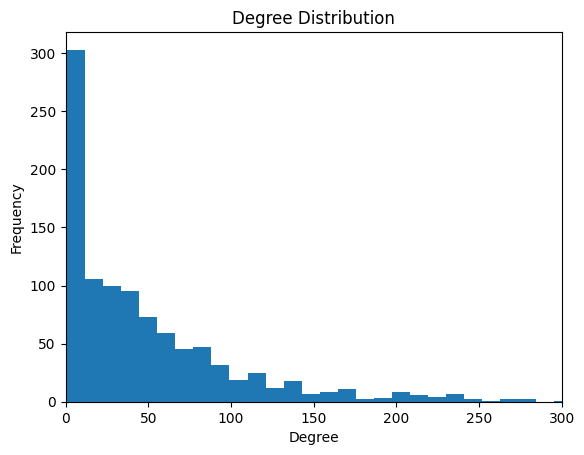

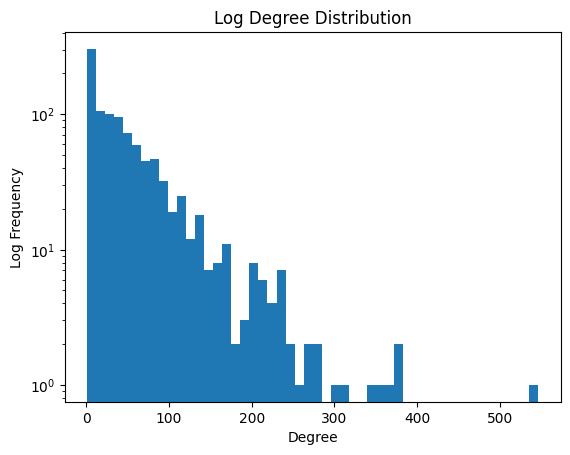

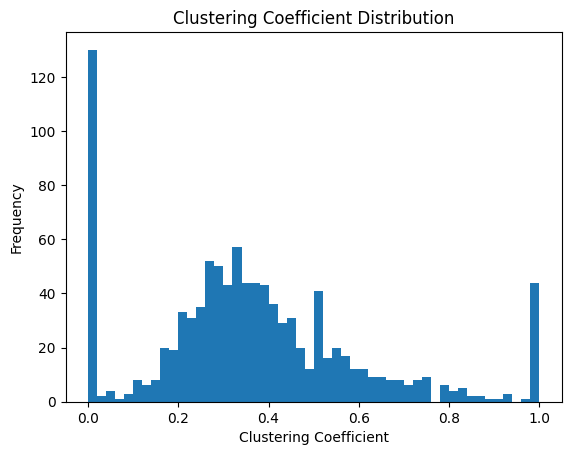

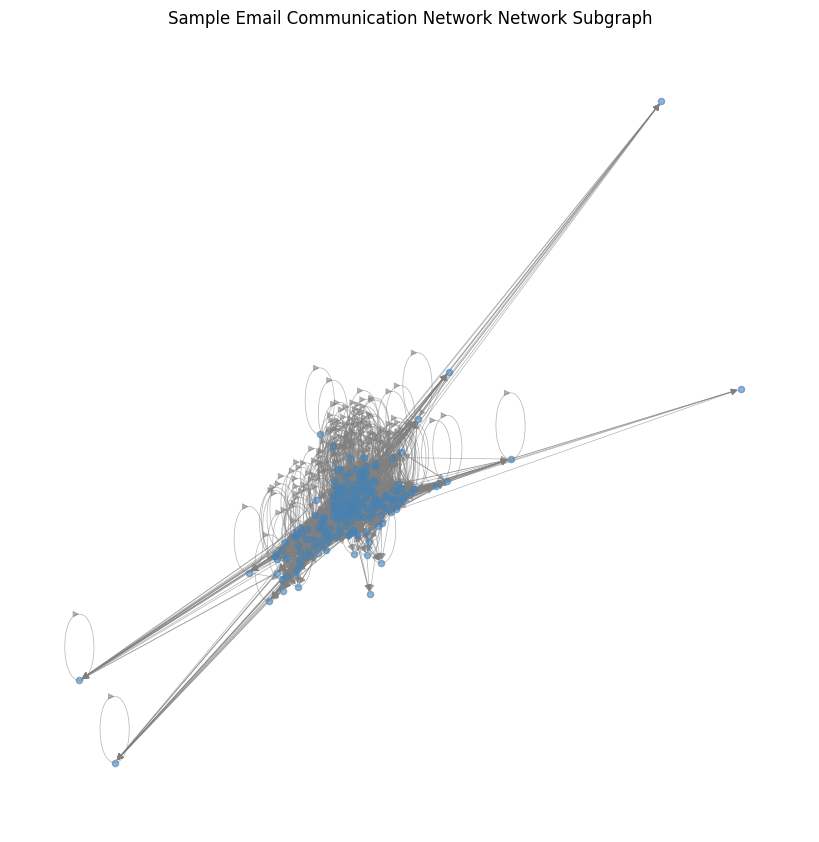

In [72]:
run_network_eda(G_email, "Email Communication Network")

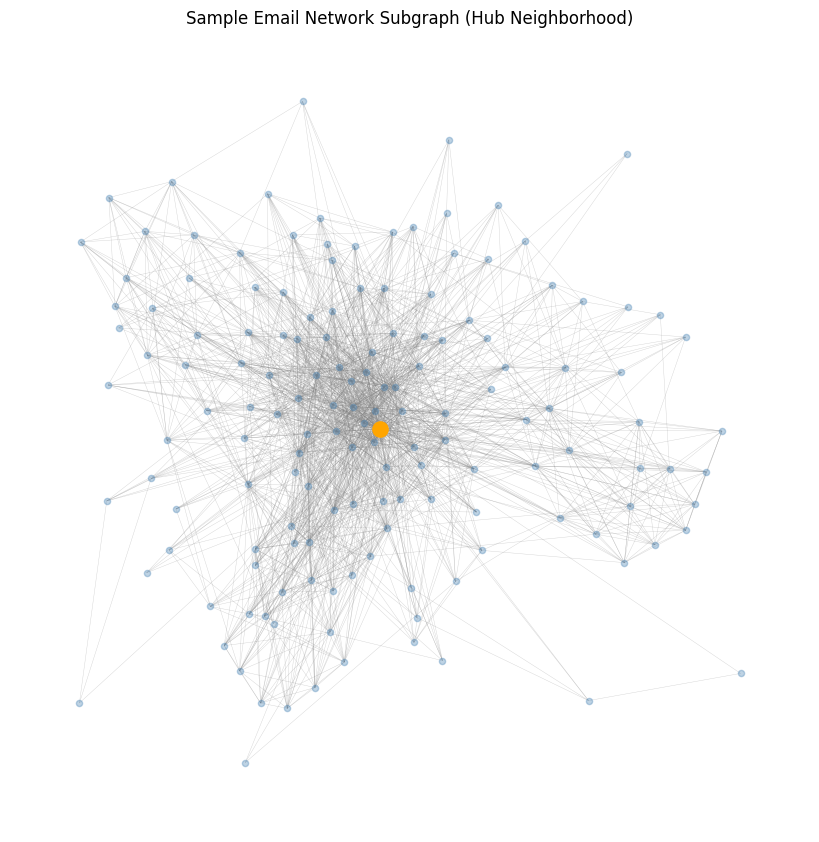

In [74]:
# I create a cleaner hub-centered visualization of the email network
import matplotlib.pyplot as plt

# I start from the email network and remove self-loops because they clutter the plot
H = G_email.copy()
H.remove_edges_from(nx.selfloop_edges(H))

# I convert to undirected so component detection and layout are cleaner
H = H.to_undirected()

# I select the largest connected component
largest_cc_nodes = max(nx.connected_components(H), key=len)
H_cc = H.subgraph(largest_cc_nodes)

# I choose the highest-degree node as the hub
seed = max(H_cc.degree(), key=lambda x: x[1])[0]

# I build a neighborhood around the hub
neighbors = list(H_cc.neighbors(seed))
neighborhood_nodes = [seed] + neighbors[:150]
subG = H_cc.subgraph(neighborhood_nodes)

# I compute a stable layout
pos = nx.spring_layout(subG, seed=42, k=0.45)

plt.figure(figsize=(8,8))
nx.draw(
    subG,
    pos=pos,
    node_size=20,
    node_color="steelblue",
    edge_color="gray",
    alpha=0.35,
    width=0.3
)

# I highlight the hub
nx.draw_networkx_nodes(
    subG,
    pos=pos,
    nodelist=[seed],
    node_size=120,
    node_color="orange"
)

plt.title("Sample Email Network Subgraph (Hub Neighborhood)")
plt.show()

The exploratory analysis of the email communication network reveals structural patterns that differ from those observed in the Facebook friendship network. The degree distribution is strongly right-skewed, with most users sending or receiving relatively few emails while a small number of individuals communicate with many others. This pattern indicates the presence of hub nodes that likely represent administrators or highly connected coordinators within the organization.

The clustering coefficient distribution is more moderate than in the Facebook network, suggesting that email communication groups are less tightly interconnected than friendship networks. Instead of dense triadic communities, the network appears to contain central communication hubs that link many otherwise separate users. The hub-neighborhood visualization above illustrates this structure, showing a highly connected central node surrounded by many lower-degree nodes. These structural patterns suggest that organizational communication networks rely heavily on central actors who facilitate the flow of information across the network.


## Dataset 3: ArXiv Collaboration Network (General Relativity)

The third dataset used in this project is the ArXiv General Relativity collaboration network from the Stanford SNAP Large Network Dataset Collection. In this dataset, nodes represent scientists and edges represent co-authorship relationships between researchers who have collaborated on a scientific paper. If two authors have written a paper together, an undirected edge connects them in the network.

Collaboration networks are commonly studied in network science because they exhibit strong community structure and triadic closure. Researchers who share collaborators are more likely to collaborate in the future, which makes this dataset particularly well suited for link prediction experiments.

In [76]:
# I download the ArXiv General Relativity collaboration network from SNAP

import urllib.request

url = "https://snap.stanford.edu/data/ca-GrQc.txt.gz"
path = f"{project_path}/ca-GrQc.txt.gz"

urllib.request.urlretrieve(url, path)

print("Saved to:", path)

Saved to: /content/drive/MyDrive/AI_Agent_Social_Network_Project/ca-GrQc.txt.gz


In [77]:
# I unzip the ArXiv collaboration dataset so it can be read as a plain edge list

import gzip
import shutil

with gzip.open(path, 'rb') as f_in:
    with open(f"{project_path}/arxiv_grqc_edges.txt", 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Unzipped to:", f"{project_path}/arxiv_grqc_edges.txt")

Unzipped to: /content/drive/MyDrive/AI_Agent_Social_Network_Project/arxiv_grqc_edges.txt


In [78]:
# I load the ArXiv collaboration edge list into a dataframe

import pandas as pd

arxiv_edges_path = f"{project_path}/arxiv_grqc_edges.txt"

edges_arxiv = pd.read_csv(
    arxiv_edges_path,
    sep="\t",
    comment="#",
    header=None,
    names=["u", "v"]
)

print("ArXiv edge sample:")
print(edges_arxiv.head())

print("Total edges:", len(edges_arxiv))

ArXiv edge sample:
      u      v
0  3466    937
1  3466   5233
2  3466   8579
3  3466  10310
4  3466  15931
Total edges: 28980


In [79]:
# I construct the ArXiv collaboration graph
# Collaboration networks are undirected because co-authorship is mutual

import networkx as nx

G_arxiv = nx.from_pandas_edgelist(
    edges_arxiv,
    source="u",
    target="v"
)

print("ArXiv nodes:", G_arxiv.number_of_nodes())
print("ArXiv edges:", G_arxiv.number_of_edges())
print("Directed:", G_arxiv.is_directed())

ArXiv nodes: 5242
ArXiv edges: 14496
Directed: False



--- ArXiv GR-QC Collaboration Network ---
Nodes: 5242
Edges: 14496
Density: 0.001055278280507905
Average clustering: 0.5296358110521362


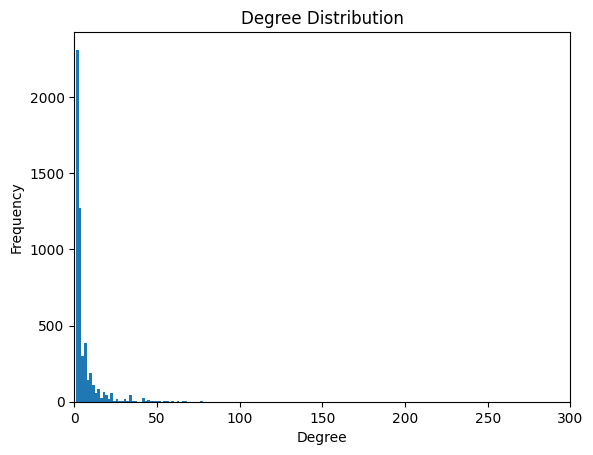

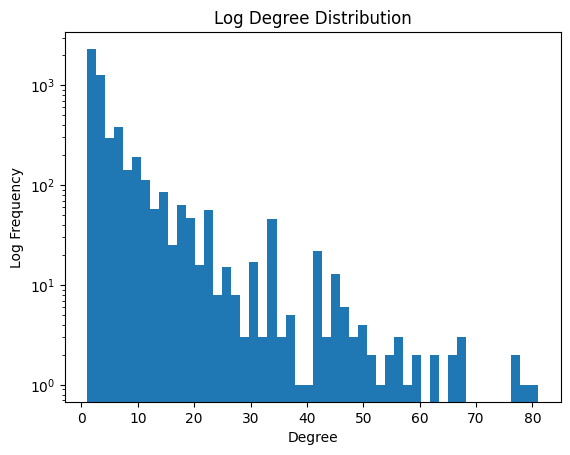

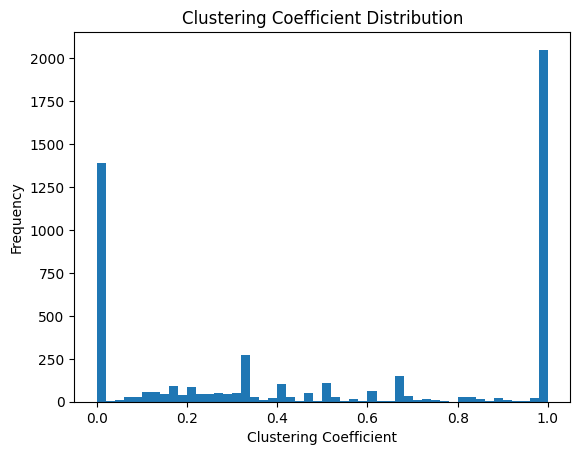

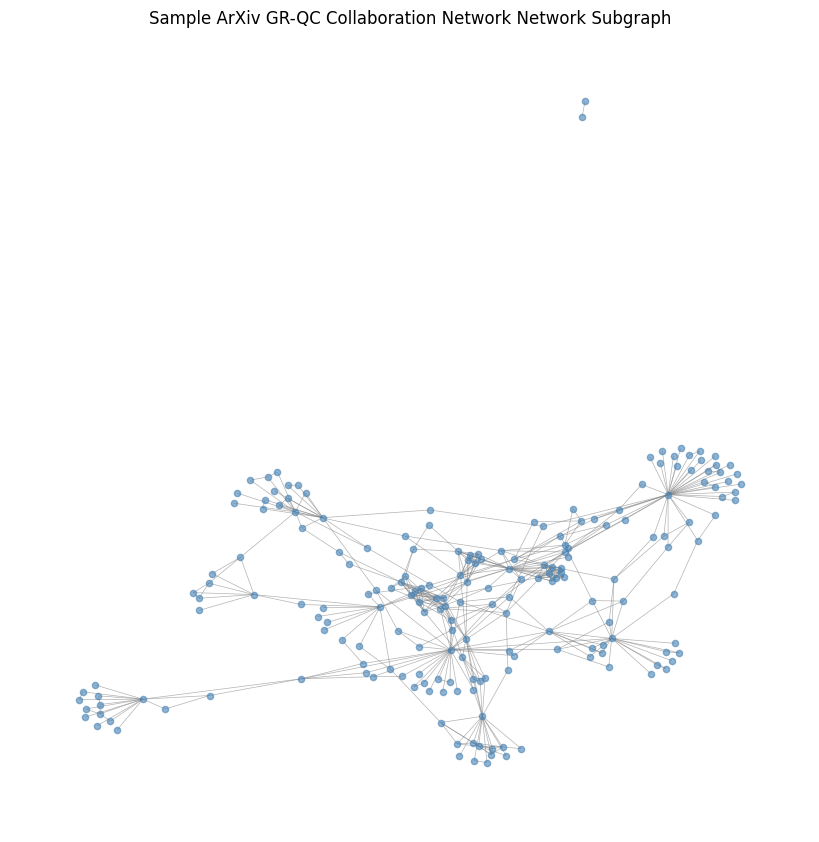

In [80]:
# I run the reusable EDA pipeline for the ArXiv collaboration network

run_network_eda(G_arxiv, "ArXiv GR-QC Collaboration Network")

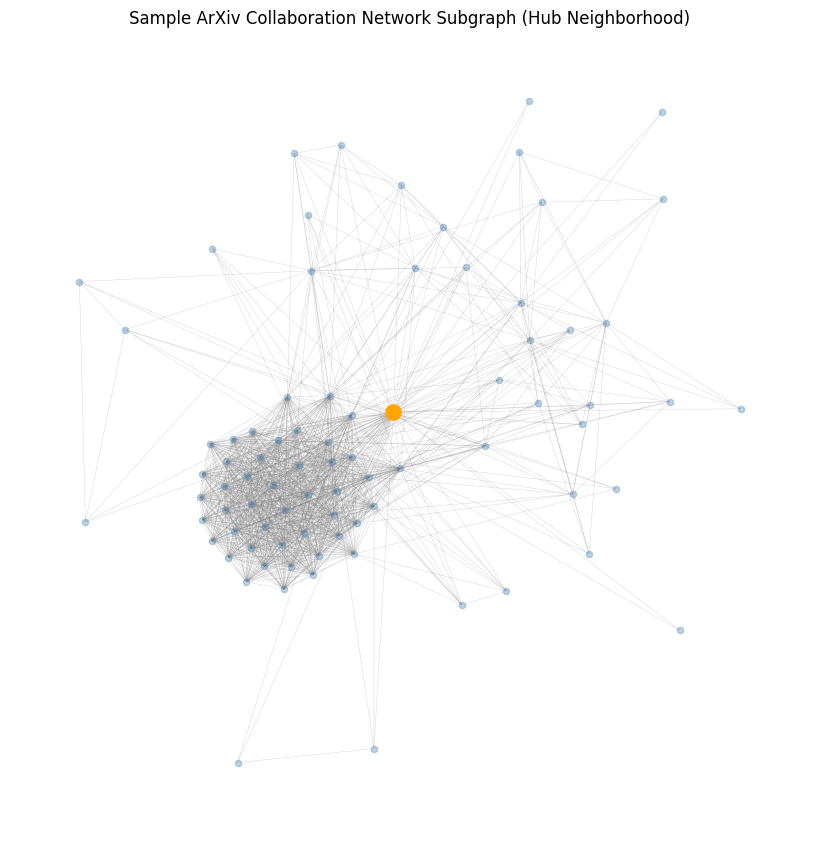

In [81]:
import networkx as nx
import matplotlib.pyplot as plt

# I copy the graph and remove self-loops if any exist
H = G_arxiv.copy()
H.remove_edges_from(nx.selfloop_edges(H))

# I select the largest connected component
largest_cc_nodes = max(nx.connected_components(H), key=len)
H_cc = H.subgraph(largest_cc_nodes)

# I choose the highest-degree node (most collaborative author)
seed = max(H_cc.degree(), key=lambda x: x[1])[0]

# I build a neighborhood around that author
neighbors = list(H_cc.neighbors(seed))
neighborhood_nodes = [seed] + neighbors[:150]
subG = H_cc.subgraph(neighborhood_nodes)

# I compute a layout
pos = nx.spring_layout(subG, seed=42, k=0.45)

plt.figure(figsize=(8,8))

nx.draw(
    subG,
    pos=pos,
    node_size=20,
    node_color="steelblue",
    edge_color="gray",
    alpha=0.35,
    width=0.3
)

# highlight the central author
nx.draw_networkx_nodes(
    subG,
    pos=pos,
    nodelist=[seed],
    node_size=120,
    node_color="orange"
)

plt.title("Sample ArXiv Collaboration Network Subgraph (Hub Neighborhood)")
plt.show()

In [82]:
print("Hub node:", seed)
print("Number of collaborators:", H_cc.degree(seed))

Hub node: 21012
Number of collaborators: 81


The exploratory analysis of the ArXiv General Relativity collaboration network reveals structural patterns that differ from those observed in both the Facebook friendship network and the email communication network. The degree distribution is strongly right-skewed, indicating that most researchers collaborate with only a small number of coauthors while a smaller number of scientists collaborate with many others. These highly connected authors often serve as hubs that link together multiple research groups.

The clustering coefficient distribution is relatively high compared to the other datasets, reflecting the collaborative nature of scientific research. When two researchers share a collaborator, they are more likely to collaborate with one another, producing tightly connected clusters of coauthors. The hub-neighborhood visualization above illustrates this structure, where a highly collaborative author connects several smaller research groups. These patterns suggest that collaboration networks are organized around clusters of researchers who repeatedly work together while remaining connected to the broader scientific community through highly collaborative individuals.